# BBB Visualizations

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
!pip install matplotlib numpy pandas --quiet

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from math import pi

matplotlib.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          7,
    'axes.titlesize':     7,
    'axes.labelsize':     7,
    'xtick.labelsize':    6,
    'ytick.labelsize':    6,
    'legend.fontsize':    6,
    'legend.framealpha':  0.85,
    'legend.edgecolor':   '0.7',
    'axes.linewidth':     0.6,
    'grid.linewidth':     0.4,
    'lines.linewidth':    1.0,
    'patch.linewidth':    0.5,
    'savefig.dpi':        600,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.02,
})

COL1 = 3.5
COL2 = 7.16

C       = ['#2166ac', '#d6604d', '#4dac26', '#762a83']
C_LIGHT = ['#92c5de', '#f4a582', '#b8e186', '#c2a5cf']

# Abbreviated optimizer labels — 'Hill Climbing' shortened so it fits at 3.5 in
OPTIMIZERS      = ['ABC', 'Bayesian', 'CMA-ES', 'Genetic', 'Hill\nClimb', 'Hyperband', 'PSO']
OPTIMIZERS_FULL = ['ABC', 'Bayesian', 'CMA-ES', 'Genetic', 'Hill Climbing', 'Hyperband', 'PSO']

print('Global style loaded.')

Global style loaded.


---
## Figure 1 – Validation vs Test F1 per Optimizer (HPO Proxy Phase)


/tmp/ipykernel_350/941423769.py:65: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.tight_layout(rect=[0, 0.03, 1, 1], h_pad=0.8)
/tmp/ipykernel_350/941423769.py:66: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig('fig1_hpo_val_vs_test.pdf')
/tmp/ipykernel_350/941423769.py:67: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig('fig1_hpo_val_vs_test.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


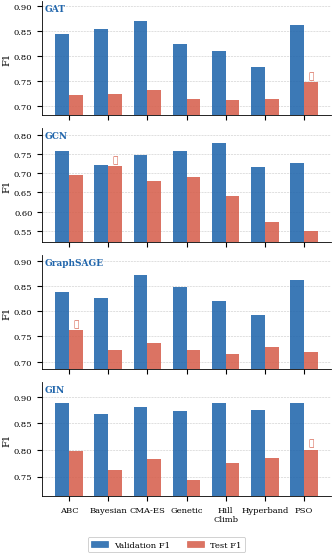

Figure 1 saved.


In [3]:
hpo_data = {
    'GAT':       {'val': [0.8440, 0.8537, 0.8693, 0.8245, 0.8097, 0.7775, 0.8623],
                  'tst': [0.7217, 0.7250, 0.7326, 0.7148, 0.7116, 0.7137, 0.7477]},
    'GCN':       {'val': [0.7576, 0.7211, 0.7477, 0.7569, 0.7771, 0.7168, 0.7274],
                  'tst': [0.6952, 0.7188, 0.6799, 0.6899, 0.6395, 0.5735, 0.5500]},
    'GraphSAGE': {'val': [0.8383, 0.8267, 0.8710, 0.8486, 0.8201, 0.7919, 0.8611],
                  'tst': [0.7617, 0.7225, 0.7373, 0.7222, 0.7147, 0.7293, 0.7195]},
    'GIN':       {'val': [0.8872, 0.8667, 0.8798, 0.8723, 0.8874, 0.8752, 0.8874],
                  'tst': [0.7977, 0.7622, 0.7834, 0.7428, 0.7748, 0.7852, 0.8007]},
}

n_opt = len(OPTIMIZERS)
x  = np.arange(n_opt)
bw = 0.35

# ── 4 rows × 1 col, shared x-axis, single-column width ───────────────────────
fig, axes = plt.subplots(4, 1,
                          figsize=(COL1, 5.6),
                          sharex=True)

for ax, (model, vals) in zip(axes, hpo_data.items()):
    b1 = ax.bar(x - bw/2, vals['val'], bw,
                label='Val F1',  color=C[0], alpha=0.88)
    b2 = ax.bar(x + bw/2, vals['tst'], bw,
                label='Test F1', color=C[1], alpha=0.88)

    # Star over best test bar
    best_idx = int(np.argmax(vals['tst']))
    ax.annotate('★',
                xy=(best_idx + bw/2, vals['tst'][best_idx] + 0.004),
                ha='center', va='bottom', fontsize=6.5, color=C[1])

    # Model name in top-left corner of each panel
    ax.text(0.01, 0.97, model,
            transform=ax.transAxes,
            fontsize=6.5, fontweight='bold', color=C[0],
            va='top', ha='left')

    # Per-panel y-range: tight around the data so bars fill the panel height
    ylo = max(0.0, min(min(vals['val']), min(vals['tst'])) - 0.03)
    yhi = max(vals['val']) + 0.04
    ax.set_ylim(ylo, yhi)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_ylabel('F1', labelpad=2)
    ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# x-axis labels only on the bottom panel
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(OPTIMIZERS, fontsize=6)

# One shared legend below all panels
handles = [
    plt.Rectangle((0, 0), 1, 1, color=C[0], alpha=0.88),
    plt.Rectangle((0, 0), 1, 1, color=C[1], alpha=0.88),
]
fig.legend(handles, ['Validation F1', 'Test F1'],
           loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.01),
           framealpha=0.85, edgecolor='0.7')

fig.tight_layout(rect=[0, 0.03, 1, 1], h_pad=0.8)
fig.savefig('fig1_hpo_val_vs_test.pdf')
fig.savefig('fig1_hpo_val_vs_test.png')
plt.show()
print('Figure 1 saved.')

---
## Figure 2 – Radar Chart: Per-Model Best Configuration (Full Training)


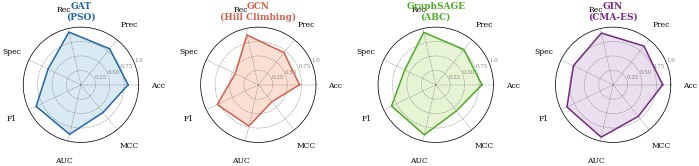

Figure 2 saved.


In [4]:
METRICS = ['Acc', 'Prec', 'Rec', 'Spec', 'F1', 'AUC', 'MCC']

best_configs = {
    'GAT\n(PSO)':          [0.8175, 0.7986, 0.9367, 0.6316, 0.8621, 0.8800, 0.6140],
    'GCN\n(Hill Climbing)':[0.7134, 0.7131, 0.8861, 0.4441, 0.7902, 0.7343, 0.3756],
    'GraphSAGE\n(ABC)':    [0.8008, 0.7823, 0.9325, 0.5954, 0.8508, 0.8890, 0.5776],
    'GIN\n(CMA-ES)':       [0.8586, 0.8583, 0.9198, 0.7632, 0.8880, 0.9307, 0.7000],
}

N = len(METRICS)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.3),
                          subplot_kw=dict(polar=True))

for ax, (label, values), color, lcolor in zip(
        axes, best_configs.items(), C, C_LIGHT):
    vals = values + values[:1]
    ax.plot(angles, vals, color=color, linewidth=1.1)
    ax.fill(angles, vals, color=lcolor, alpha=0.35)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(METRICS, size=5.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'],
                        size=4.0, color='grey')
    ax.grid(color='grey', linewidth=0.35, linestyle='--')
    ax.set_title(label, size=6.5, fontweight='bold', pad=6, color=color)
    ax.spines['polar'].set_linewidth(0.5)

fig.tight_layout(w_pad=1.5)
fig.savefig('fig2_radar_best_configs.pdf')
fig.savefig('fig2_radar_best_configs.png')
plt.show()
print('Figure 2 saved.')

---
## Figure 3 – Cross-Dataset Generalization (AUC & MCC)


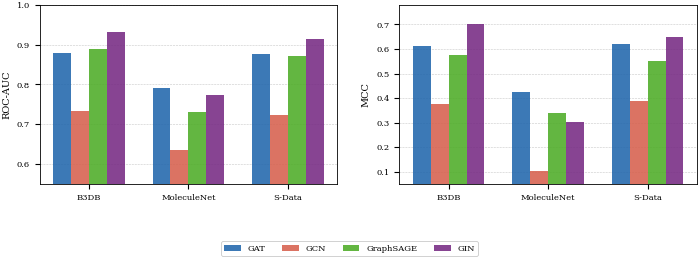

Figure 3 saved.


In [5]:
DATASETS   = ['B3DB', 'MoleculeNet', 'S-Data']
MODELS_GNN = ['GAT', 'GCN', 'GraphSAGE', 'GIN']

auc_vals = {
    'GAT':       [0.8800, 0.7912, 0.8776],
    'GCN':       [0.7343, 0.6342, 0.7235],
    'GraphSAGE': [0.8890, 0.7318, 0.8713],
    'GIN':       [0.9307, 0.7746, 0.9154],
}
mcc_vals = {
    'GAT':       [0.6140, 0.4243, 0.6203],
    'GCN':       [0.3756, 0.1014, 0.3899],
    'GraphSAGE': [0.5776, 0.3401, 0.5503],
    'GIN':       [0.7000, 0.3013, 0.6506],
}

x        = np.arange(len(DATASETS))
total_w  = 0.72
bw       = total_w / len(MODELS_GNN)
offsets  = np.linspace(-total_w/2 + bw/2, total_w/2 - bw/2, len(MODELS_GNN))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(COL2, 2.4))

for i, (model, color) in enumerate(zip(MODELS_GNN, C)):
    ax1.bar(x + offsets[i], auc_vals[model], bw, label=model, color=color, alpha=0.88)
    ax2.bar(x + offsets[i], mcc_vals[model], bw, label=model, color=color, alpha=0.88)

for ax, metric, ylim in [(ax1, 'ROC-AUC', (0.55, 1.0)),
                          (ax2, 'MCC',     (0.05, 0.78))]:
    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel(metric)
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.7)
    ax.set_axisbelow(True)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12),
           framealpha=0.85, edgecolor='0.7')

fig.tight_layout(rect=[0, 0.08, 1, 1], w_pad=2.5)
fig.savefig('fig3_cross_dataset_generalization.pdf')
fig.savefig('fig3_cross_dataset_generalization.png')
plt.show()
print('Figure 3 saved.')

---
## Figure 4 – Model Comparison on B3DB (All 9 Models, F1 & MCC)
**Full-width placement (figure*).**

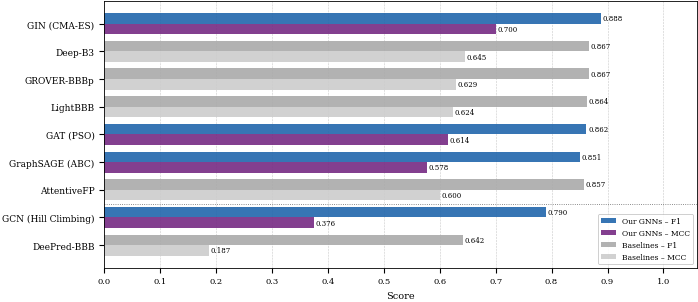

Figure 4 saved.


In [6]:
from matplotlib.patches import Patch

models_all = [
    'DeePred-BBB',
    'GCN (Hill Climbing)',
    'AttentiveFP',
    'GraphSAGE (ABC)',
    'GAT (PSO)',
    'LightBBB',
    'GROVER-BBBp',
    'Deep-B3',
    'GIN (CMA-ES)',
]
f1_all  = [0.6421, 0.7902, 0.8573, 0.8508, 0.8621, 0.8635, 0.8670, 0.8668, 0.8880]
mcc_all = [0.1870, 0.3756, 0.5996, 0.5776, 0.6140, 0.6235, 0.6288, 0.6450, 0.7000]

GNN_MODELS     = {'GCN (Hill Climbing)', 'GraphSAGE (ABC)', 'GAT (PSO)', 'GIN (CMA-ES)'}
bar_colors_f1  = [C[0]      if m in GNN_MODELS else '#aaaaaa' for m in models_all]
bar_colors_mcc = [C[3]      if m in GNN_MODELS else '#cccccc' for m in models_all]

y  = np.arange(len(models_all))
bw = 0.38

fig, ax = plt.subplots(figsize=(COL2, 3.2))

bars_f1  = ax.barh(y + bw/2, f1_all,  bw, color=bar_colors_f1,  alpha=0.90)
bars_mcc = ax.barh(y - bw/2, mcc_all, bw, color=bar_colors_mcc, alpha=0.90)

for bar, val in zip(bars_f1, f1_all):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=5)
for bar, val in zip(bars_mcc, mcc_all):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=5)

ax.set_yticks(y)
ax.set_yticklabels(models_all, fontsize=6.5)
ax.set_xlabel('Score')
ax.set_xlim(0, 1.06)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
ax.axhline(y=1.5, color='0.4', linewidth=0.6, linestyle=':')

legend_elements = [
    Patch(facecolor=C[0],      alpha=0.9, label='Our GNNs – F1'),
    Patch(facecolor=C[3],      alpha=0.9, label='Our GNNs – MCC'),
    Patch(facecolor='#aaaaaa', alpha=0.9, label='Baselines – F1'),
    Patch(facecolor='#cccccc', alpha=0.9, label='Baselines – MCC'),
]
ax.legend(handles=legend_elements,
          loc='lower right', fontsize=5.5,
          framealpha=0.88, edgecolor='0.7')

fig.tight_layout()
fig.savefig('fig4_model_comparison_b3db.pdf')
fig.savefig('fig4_model_comparison_b3db.png')
plt.show()
print('Figure 4 saved.')